### Question 1

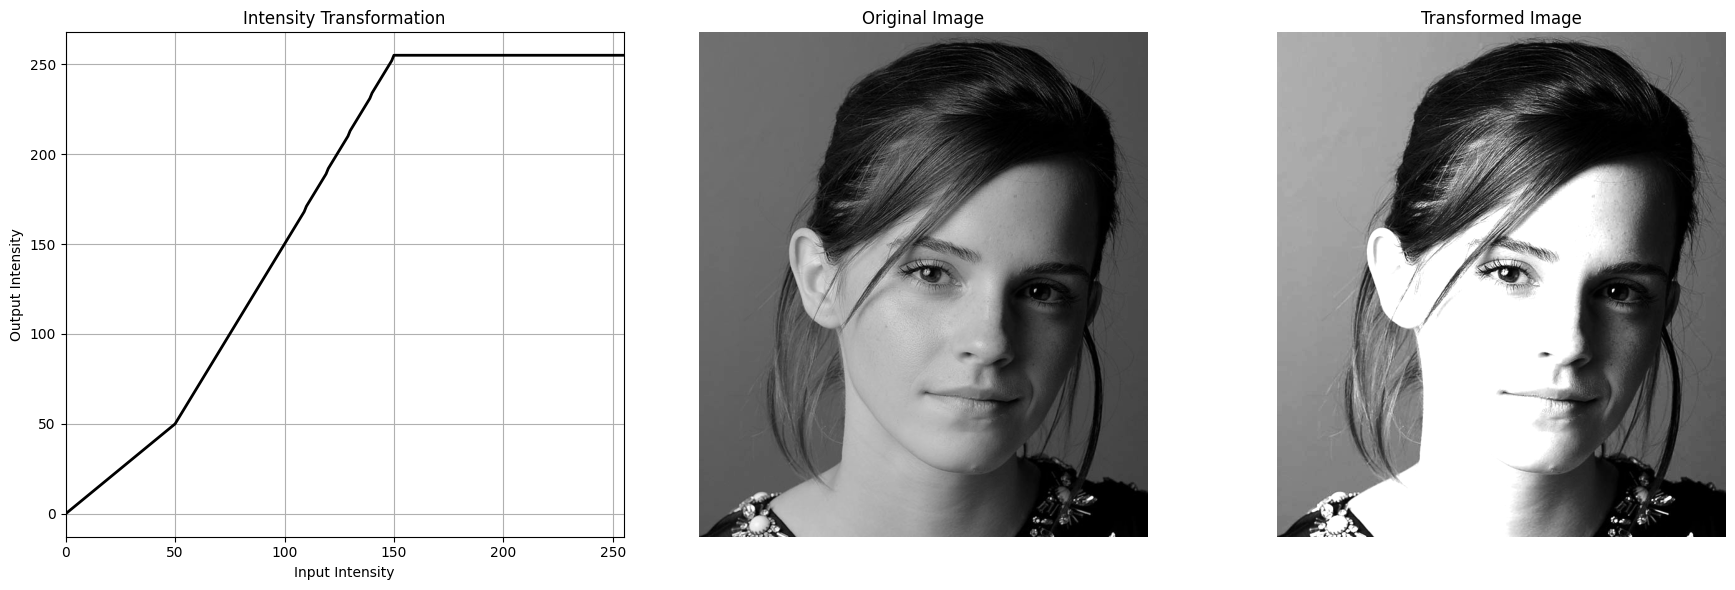

In [2]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np

def intensity_transform(im, breakpoints):
    # Applies a piecewise linear intensity transformation using a lookup table (LUT)

    points = np.array(breakpoints)
    x_in, y_out = points[:, 0], points[:, 1]

    lut = np.interp(np.arange(256), x_in, y_out).astype(np.uint8)

    transformed_im = cv2.LUT(im, lut)
    return transformed_im, lut


breakpoints_1= [[0, 0], [50, 50], [100, 150], [150, 255], [255, 255]]

im = cv2.imread("images/q1.jpeg", cv2.IMREAD_GRAYSCALE)

transformed_im_1, lut_1 = intensity_transform(im, breakpoints_1)

# Plotting transformation curve and side-by-side images 
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].plot(np.arange(256), lut_1, linestyle='solid', linewidth= 2, color= 'black')
ax[0].set_title('Intensity Transformation') 
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].grid(True)

ax[1].imshow(im, cmap="gray")
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(transformed_im_1, cmap="gray")
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

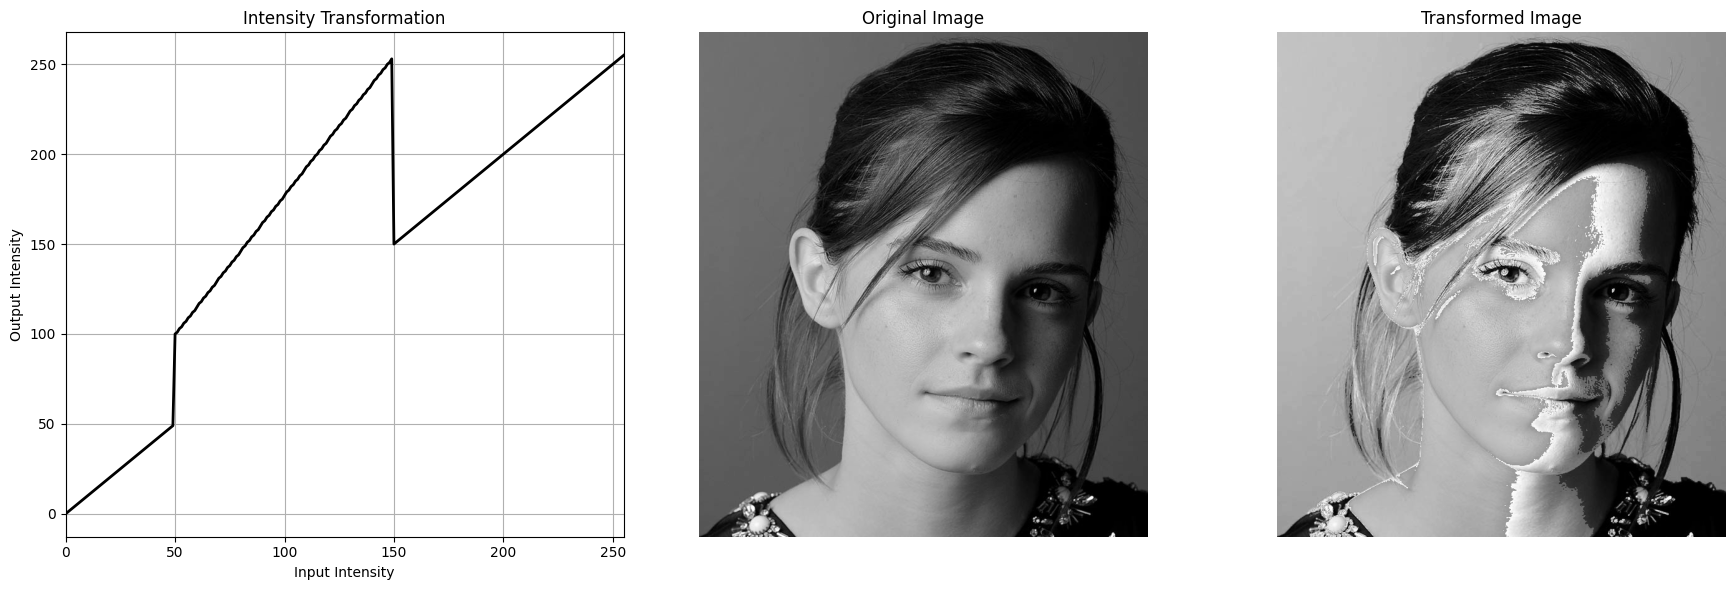

In [3]:
breakpoints_2= [[0, 0], [50, 50], [50, 100], [150, 255], [150, 150], [255, 255]]

transformed_im_2, lut_2 = intensity_transform(im, breakpoints_2)

# Plotting transformation curve and side-by-side images 
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].plot(np.arange(256), lut_2, linestyle='solid', linewidth= 2, color= 'black')
ax[0].set_title('Intensity Transformation') 
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].grid(True)

ax[1].imshow(im, cmap="gray")
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(transformed_im_2, cmap="gray")
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

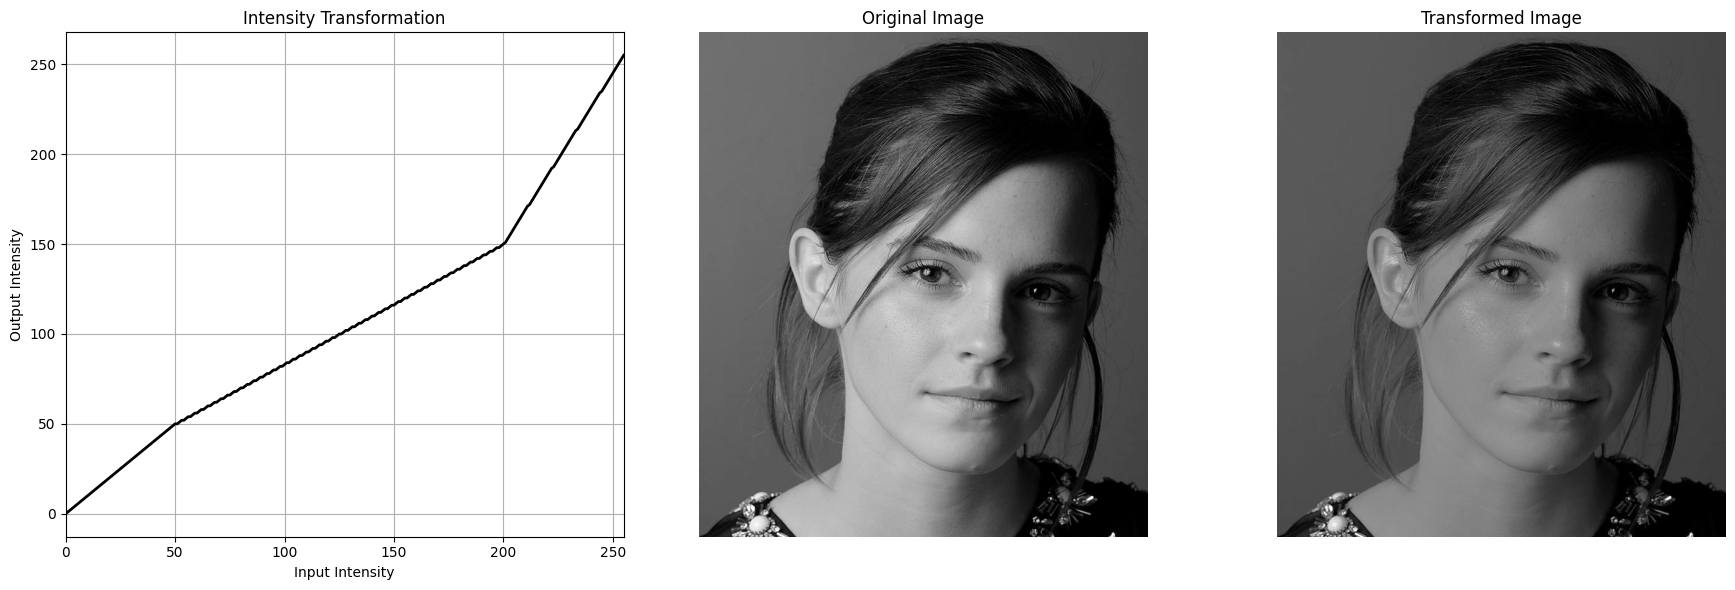

In [4]:
breakpoints_3= [[0, 0], [50, 50], [200, 150], [255, 255]]

transformed_im_3, lut_3 = intensity_transform(im, breakpoints_3)

# Plotting transformation curve and side-by-side images 
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].plot(np.arange(256), lut_3, linestyle='solid', linewidth= 2, color= 'black')
ax[0].set_title('Intensity Transformation') 
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].grid(True)

ax[1].imshow(im, cmap="gray")
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(transformed_im_3, cmap="gray")
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Question 2

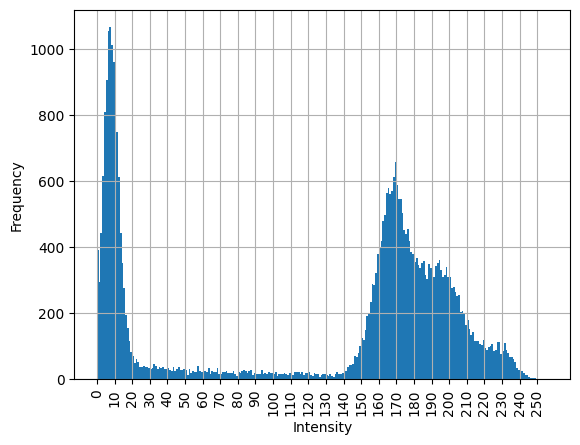

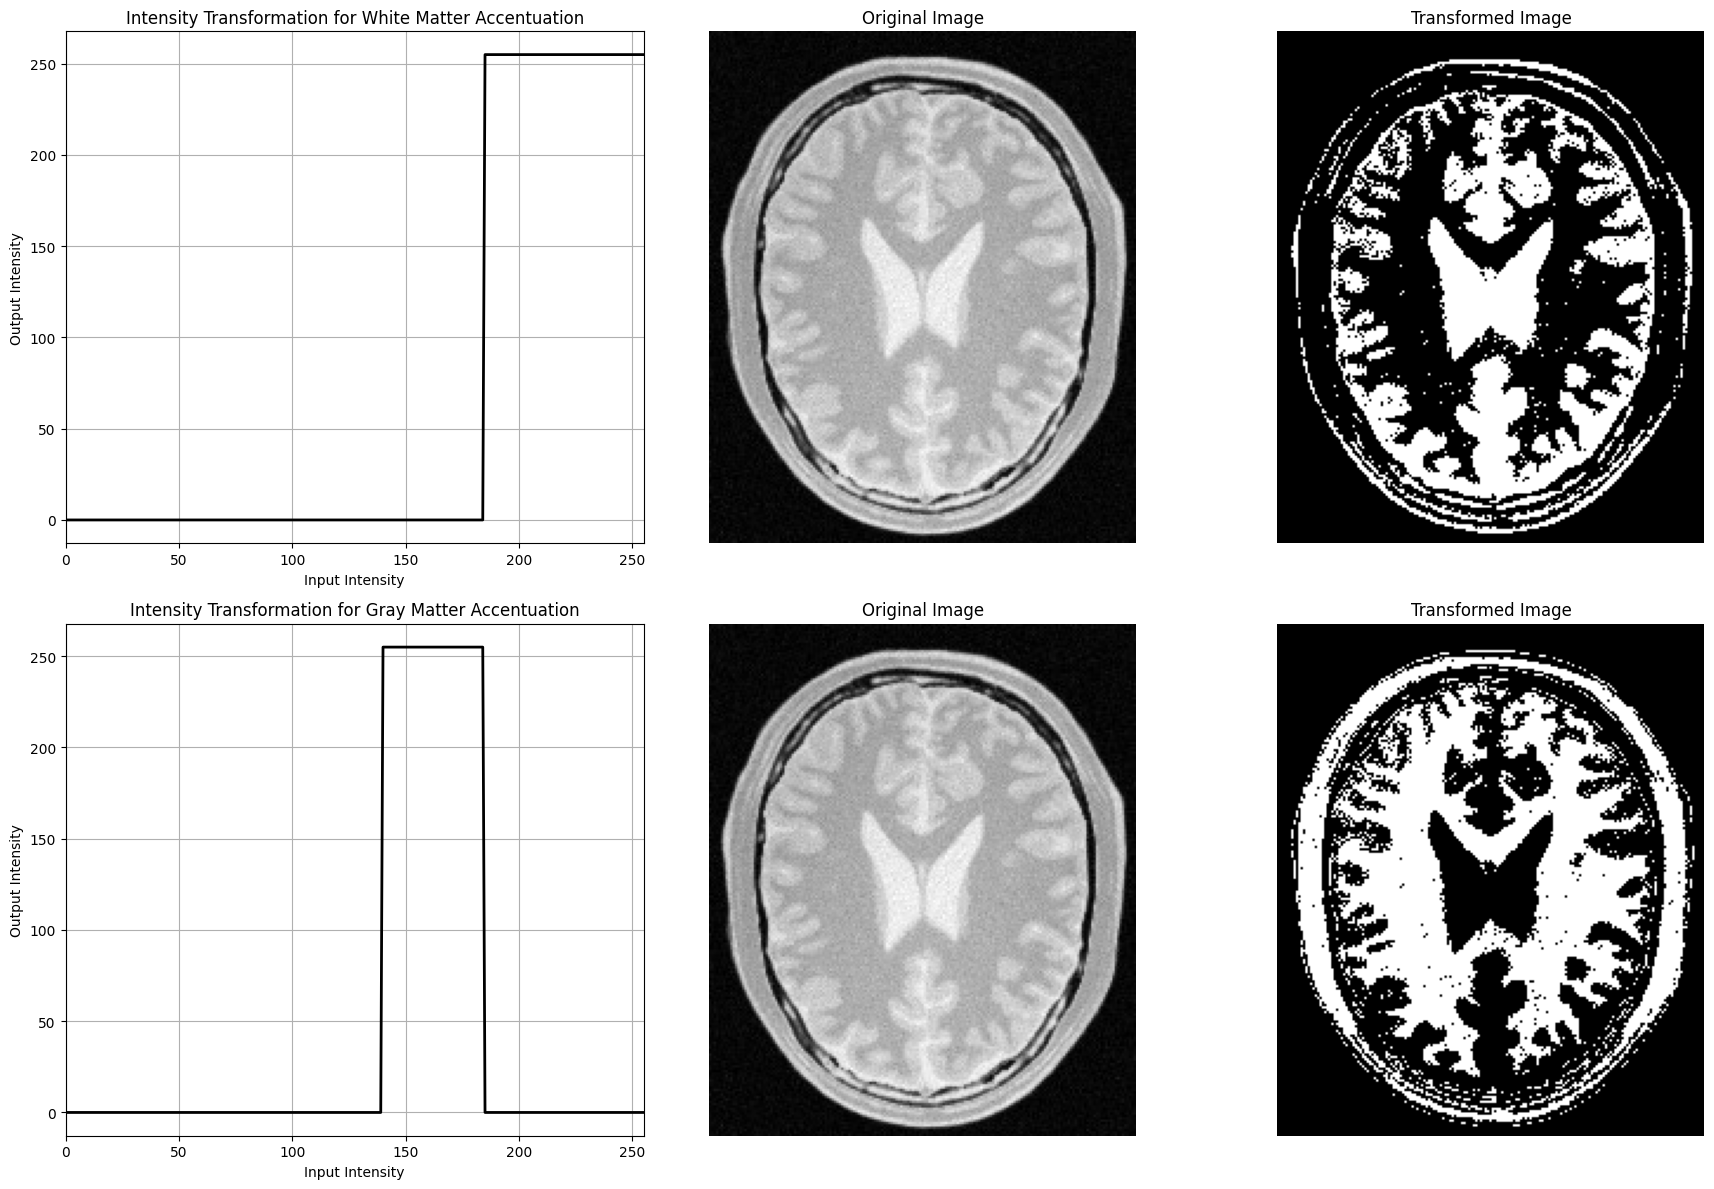

In [5]:
breakpoints_4= [[0, 0], [184, 0], [185, 255],[255, 255]] 
breakpoints_5= [[0, 0], [139, 0], [140, 255],[184, 255], [185, 0], [255, 0]]

im_1 = cv2.imread("images/q2.jpeg", cv2.IMREAD_GRAYSCALE)

transformed_im_4, lut_4 = intensity_transform(im_1, breakpoints_4)
transformed_im_5, lut_5 = intensity_transform(im_1, breakpoints_5)

# plotting histogram of the original image to identify the intensity distribution
plt.hist(im_1.ravel(), bins=256, range=[0,256])
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xticks(np.arange(0, 256, 10), rotation=90)
plt.grid(True)
plt.show()

# Plotting transformation curve and side-by-side images 
fig, ax = plt.subplots(2, 3, figsize=(18, 12))

ax[0][0].plot(np.arange(256), lut_4, linestyle='solid', linewidth= 2, color= 'black')
ax[0][0].set_title('Intensity Transformation for White Matter Accentuation') 
ax[0][0].set_xlabel('Input Intensity')
ax[0][0].set_ylabel('Output Intensity')
ax[0][0].set_xlim([0, 255])
ax[0][0].grid(True)

ax[0][1].imshow(im_1, cmap="gray")
ax[0][1].set_title('Original Image')
ax[0][1].axis('off')

ax[0][2].imshow(transformed_im_4, cmap="gray")
ax[0][2].set_title('Transformed Image')
ax[0][2].axis('off')

ax[1][0].plot(np.arange(256), lut_5, linestyle='solid', linewidth= 2, color= 'black')
ax[1][0].set_title('Intensity Transformation for Gray Matter Accentuation') 
ax[1][0].set_xlabel('Input Intensity')
ax[1][0].set_ylabel('Output Intensity')
ax[1][0].set_xlim([0, 255])
ax[1][0].grid(True)

ax[1][1].imshow(im_1, cmap="gray")
ax[1][1].set_title('Original Image')
ax[1][1].axis('off')

ax[1][2].imshow(transformed_im_5, cmap="gray")
ax[1][2].set_title('Transformed Image')
ax[1][2].axis('off')

plt.tight_layout()
plt.show()

select the range from 140 to 185 as gray matter range and the range from 185 to 255 as white matter range.

### Question 3

Applied Gamma value: 0.7


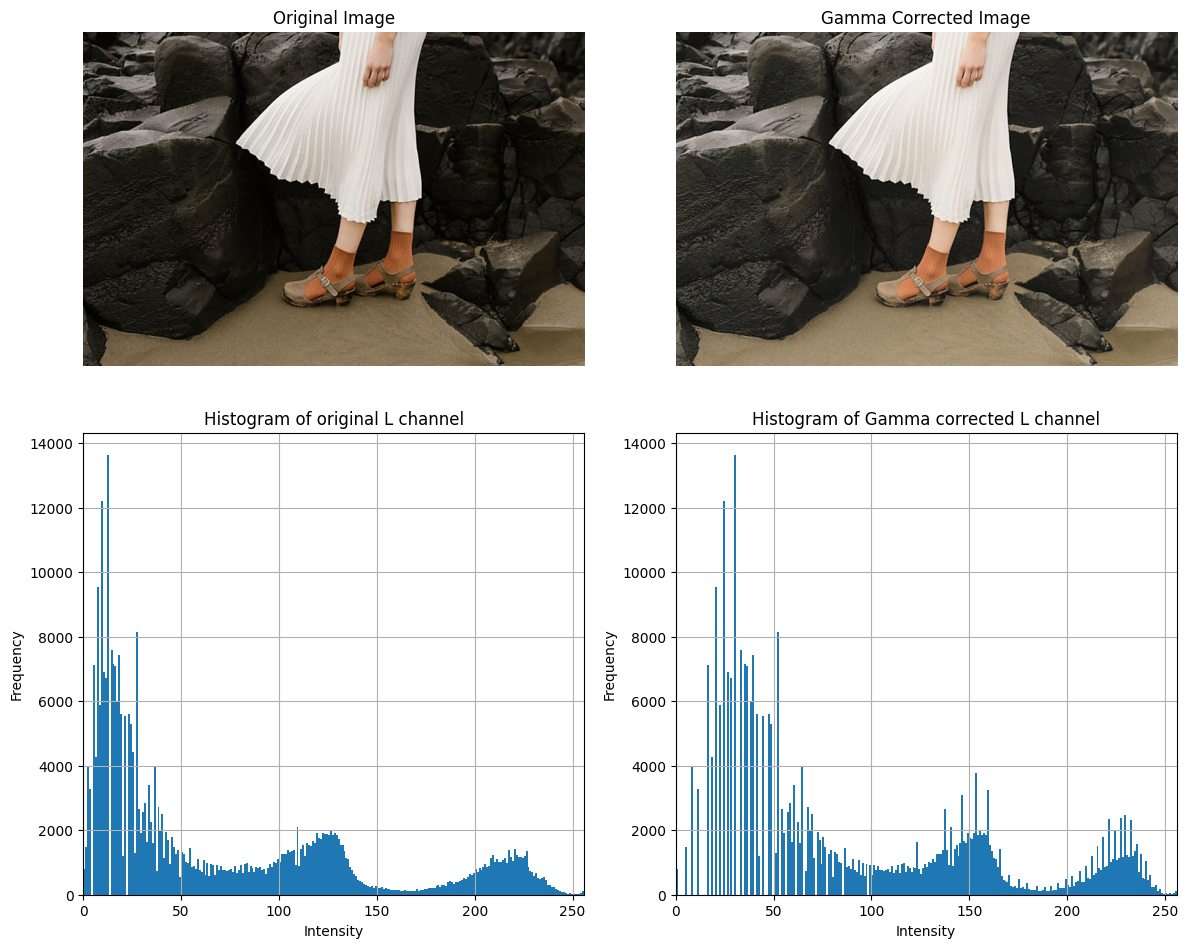

In [6]:
im_bgr = cv2.imread("images/WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg")

# separating the L*a*b* channels
L, a, b = cv2.split(cv2.cvtColor(im_bgr, cv2.COLOR_BGR2LAB))

# Applying Gamma correction to the L channel
gamma = 0.7
print(f"Applied Gamma value: {gamma}")

lut_gamma = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype(np.uint8)
L_corrected = cv2.LUT(L, lut_gamma)

# merge corrected L channel with original a and b channels
im_lab_corrected = cv2.merge([L_corrected, a, b])

fig, ax = plt.subplots(2, 2, figsize= (12,10))

# Plotting the original image
ax[0][0].imshow(cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB))
ax[0][0].set_title('Original Image')
ax[0][0].axis('off')

# Plotting Gamma corrected image
ax[0][1].imshow(cv2.cvtColor(im_lab_corrected, cv2.COLOR_LAB2RGB))
ax[0][1].set_title('Gamma Corrected Image')
ax[0][1].axis('off')

# plotting the histogram of original L channel
ax[1][0].hist(L.ravel(), bins= 256, range= [0, 256])
ax[1][0].set_title('Histogram of original L channel')
ax[1][0].set_xlabel('Intensity')
ax[1][0].set_ylabel('Frequency')
ax[1][0].set_xlim([0, 256])
ax[1][0].grid(True)

# plotting the histogram of Gamma corrected L channel
ax[1][1].hist(L_corrected.ravel(), bins= 256, range= [0, 256])
ax[1][1].set_title('Histogram of Gamma corrected L channel')
ax[1][1].set_xlabel('Intensity')
ax[1][1].set_ylabel('Frequency')
ax[1][1].set_xlim([0, 256])
ax[1][1].grid(True)

plt.tight_layout()
plt.show()

### Question 4

In [7]:
im_2 = cv2.imread("images/WhatsApp Image 2026-09-09 at 20.02.441.jpeg")

# converting the image to HSV color space
im_hsv = cv2.cvtColor(im_2, cv2.COLOR_BGR2HSV)

# separate into planes
hue_plane = im_hsv[:, :, 0]
saturation_plane = im_hsv[:, :, 1]
value_plane = im_hsv[:, :, 2]

In [8]:
# Apply the aforementioned intensity transformation to the saturation plane

a_val = 0.95
sigma = 70.0

x = np.arange(256, dtype=np.float32)
boost = a_val * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma**2))) 
fx = np.minimum(x + boost, 255.0).astype(np.uint8)

corrected_saturation_plane = cv2.LUT(saturation_plane, fx)

print(f"Applied a value: {a_val}")

Applied a value: 0.95


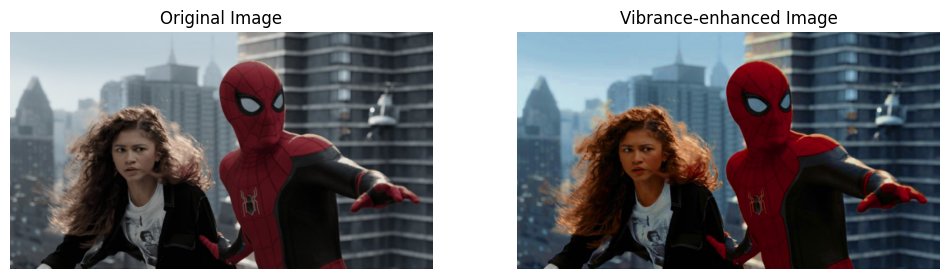

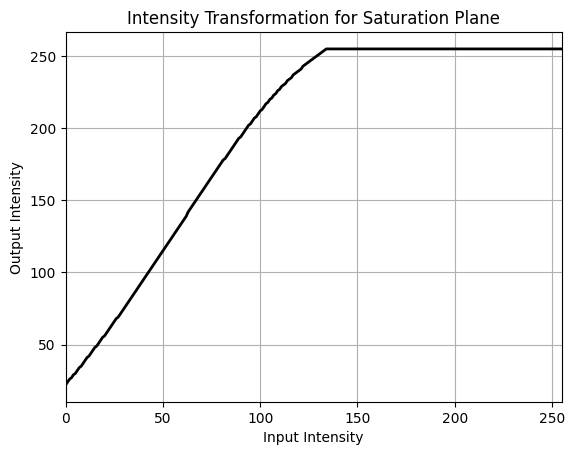

In [9]:
# recombining three planes back to get vibrance-enhanced image
im_hsv_corrected = cv2.merge([hue_plane, corrected_saturation_plane, value_plane])

# showing all plots
fig, ax = plt.subplots(1,2, figsize= (12, 6))

ax[0].imshow(cv2.cvtColor(im_2, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(cv2.cvtColor(im_hsv_corrected, cv2.COLOR_HSV2RGB))
ax[1].set_title('Vibrance-enhanced Image')
ax[1].axis('off')
plt.show()


plt.plot(np.arange(256), fx, linestyle='solid', linewidth= 2, color= 'black')
plt.title('Intensity Transformation for Saturation Plane')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim([0, 255])
plt.grid(True)

plt.show()


### Question 5

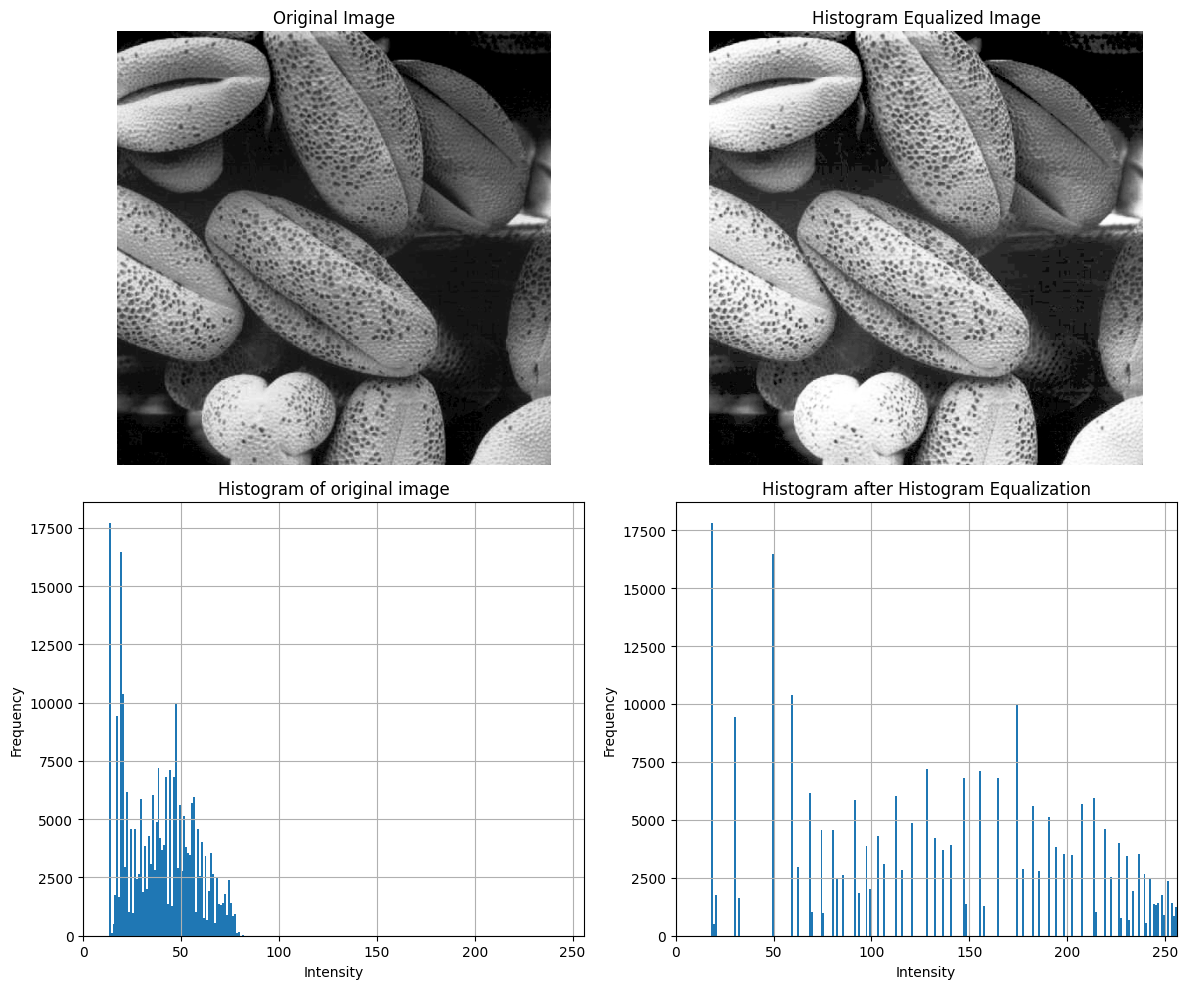

In [10]:
def custom_histogram_equalization(im_gray):
    # Equalize the histogram of grayscale image

    # Compute histogram
    hist, bin_edges = np.histogram(im_gray.flatten(), bins=256, range=(0, 256))

    # Compute PMF and CDF 
    pmf = hist / im_gray.size
    cdf = np.cumsum(pmf)

    # Map CDF to intensity range
    lookup_table = np.round(cdf * 255).astype(np.uint8)

    # Apply mapping 
    equalized_im = lookup_table[im_gray]
    return equalized_im

im_3 = cv2.imread("images/shells.tif", cv2.IMREAD_GRAYSCALE)

equlaized_im_3 = custom_histogram_equalization(im_3)

fig, ax = plt.subplots(2, 2, figsize= (12,10))

# plotting the original image
ax[0][0].imshow(im_3, cmap='gray')
ax[0][0].set_title('Original Image')
ax[0][0].axis('off')

# Plotting histogram qualized image
ax[0][1].imshow(equlaized_im_3, cmap='gray')
ax[0][1].set_title('Histogram Equalized Image')
ax[0][1].axis('off')

# plotting the Histogram of original image
ax[1][0].hist(im_3.flatten(), bins= 256, range= [0, 256])
ax[1][0].set_title('Histogram of original image')
ax[1][0].set_xlabel('Intensity')
ax[1][0].set_ylabel('Frequency')
ax[1][0].set_xlim([0, 256])
ax[1][0].grid(True)

# plotting the Histogram after Histogram Equalization
ax[1][1].hist(equlaized_im_3.flatten(), bins= 256, range= [0, 256])
ax[1][1].set_title('Histogram after Histogram Equalization')
ax[1][1].set_xlabel('Intensity')
ax[1][1].set_ylabel('Frequency')
ax[1][1].set_xlim([0, 256])
ax[1][1].grid(True)

plt.tight_layout()
plt.show()


### Question 6

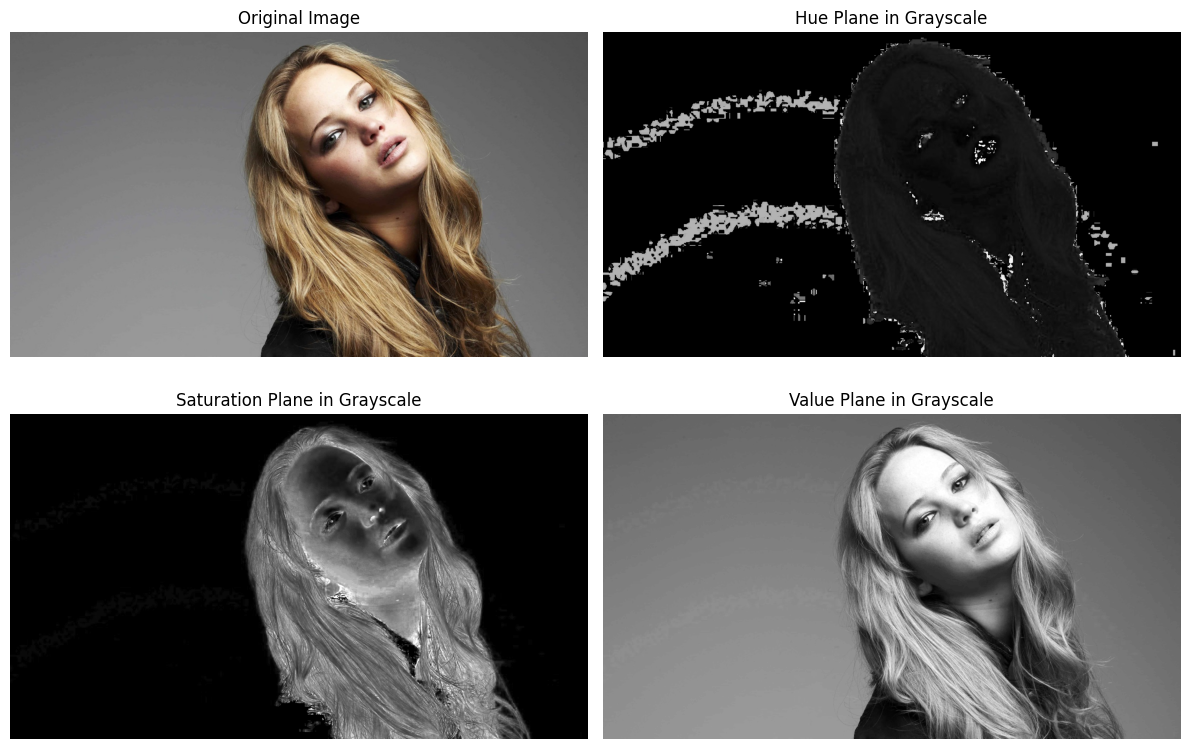

In [34]:
im_4 = cv2.imread("images/WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg")

# converting the image to HSV color space
im_4_hsv = cv2.cvtColor(im_4, cv2.COLOR_BGR2HSV)

# separate into planes
hue_plane = im_4_hsv[:, :, 0]
saturation_plane = im_4_hsv[:, :, 1]
value_plane = im_4_hsv[:, :, 2]

# showing all planes of HSV color space
fig, ax = plt.subplots(2,2, figsize= (12, 8))

ax[0][0].imshow(cv2.cvtColor(im_4, cv2.COLOR_BGR2RGB))
ax[0][0].set_title('Original Image')
ax[0][0].axis('off')

ax[0][1].imshow(hue_plane, cmap='gray')
ax[0][1].set_title('Hue Plane in Grayscale')
ax[0][1].axis('off')

ax[1][0].imshow(saturation_plane, cmap='gray')
ax[1][0].set_title('Saturation Plane in Grayscale')
ax[1][0].axis('off')

ax[1][1].imshow(value_plane, cmap='gray')
ax[1][1].set_title('Value Plane in Grayscale')
ax[1][1].axis('off')

plt.tight_layout()
plt.show()

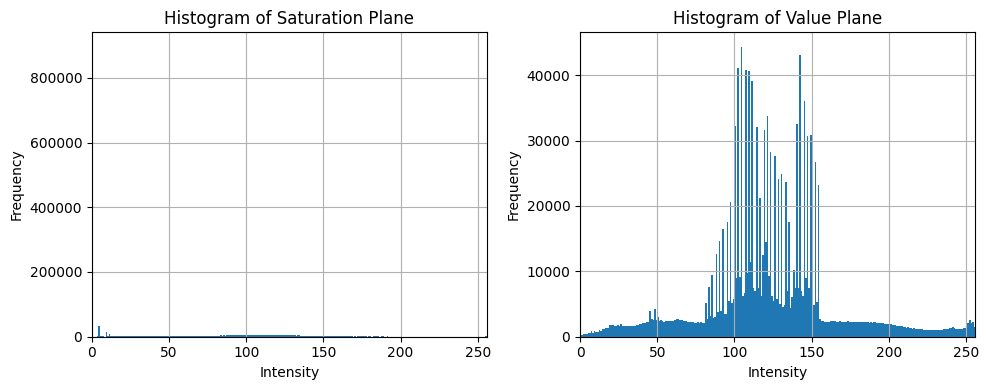

In [44]:
fig, ax = plt.subplots(1, 2, figsize= (10,4))

# plotting the Histogram of Saturation Plane
ax[0].hist(saturation_plane.flatten(), bins= 256, range= [0, 256])
ax[0].set_title('Histogram of Saturation Plane')
ax[0].set_xlabel('Intensity')
ax[0].set_ylabel('Frequency')
ax[0].set_xlim([0, 256])
ax[0].grid(True)

# plotting the Histogram of Value Plane
ax[1].hist(value_plane.flatten(), bins= 256, range= [0, 256])
ax[1].set_title('Histogram of Value Plane')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim([0, 256])
ax[1].grid(True)

plt.tight_layout()
plt.show()

Selected the Saturation plane to extract the foreground mask after looking at the grayscale images and histograms of 3 planes.

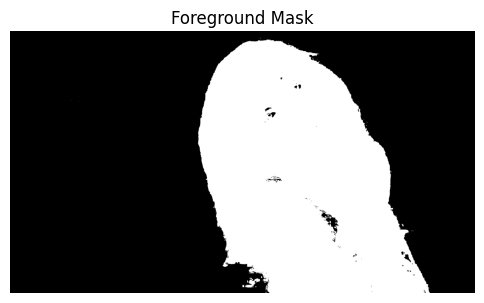

In [45]:
# threshold saturation plane
ret_value, mask = cv2.threshold(saturation_plane,14, 255, cv2.THRESH_BINARY)
binary_mask = (mask > 0).astype(np.uint8)

# display the foreground mask
plt.figure(figsize=(6, 6))
plt.imshow(binary_mask, cmap='gray')
plt.title('Foreground Mask')
plt.axis('off')
plt.show()

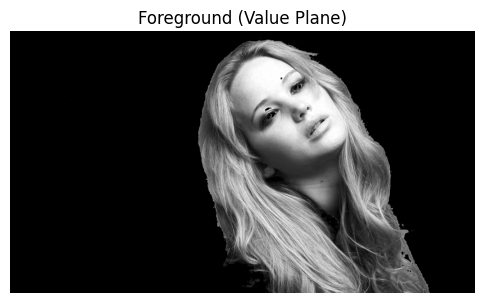

In [46]:
# Extract foreground on the Value plane
foreground = cv2.bitwise_and(value_plane, value_plane, mask=binary_mask)

plt.figure(figsize=(6, 6))
plt.imshow(foreground, cmap='gray')
plt.title('Foreground (Value Plane)')
plt.axis('off')
plt.show()

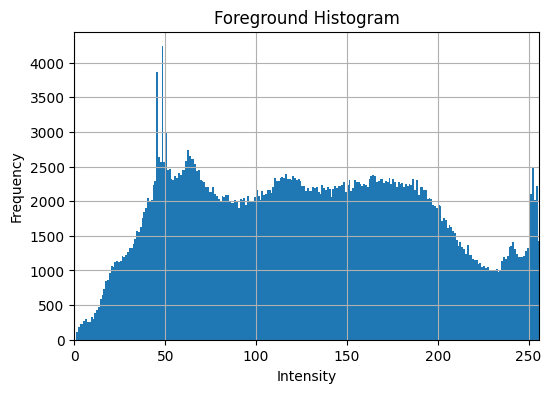

In [47]:
# Compute histogram of the foreground pixels
fg_pixels = value_plane[binary_mask == 1]  
hist, bin_edges = np.histogram(fg_pixels, bins=256, range=(0, 256))

# Histogram of the foreground pixels
plt.figure(figsize=(6, 4))
plt.hist(fg_pixels, bins=256, range =[0, 256])
plt.title('Foreground Histogram')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.grid(True)
plt.show()

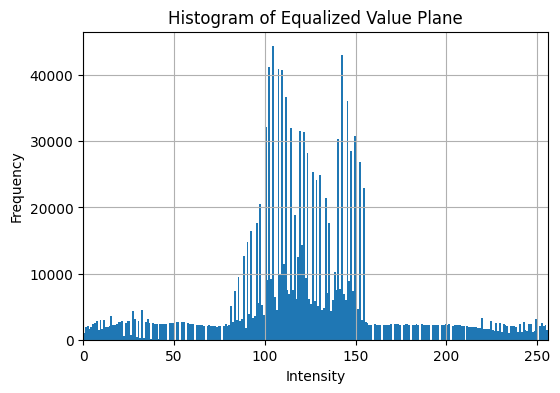

In [48]:
# calculate the CDF of the foreground histogram
cdf_fg = np.cumsum(hist / fg_pixels.size) 
lut_fg = np.round(cdf_fg * 255).astype(np.uint8)  


# Apply equalization to foreground Value channel
value_equalized = value_plane.copy()
value_equalized[binary_mask == 1] = lut_fg[value_plane[binary_mask == 1]]

plt.figure(figsize=(6, 4))
plt.hist(value_equalized.flatten(), bins= 256, range= [0, 256])
plt.title('Histogram of Equalized Value Plane')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.grid(True)
plt.show()

im_4_fg_equalized = cv2.merge([hue_plane, saturation_plane, value_equalized])

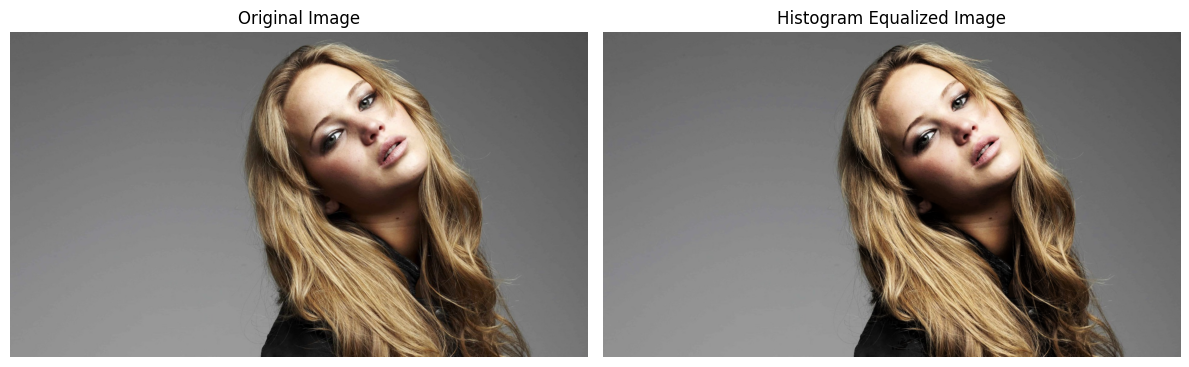

In [40]:
fig, ax = plt.subplots(1, 2, figsize= (12,5))

# plotting the original image
ax[0].imshow(cv2.cvtColor(im_4, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

# Plotting histogram qualized image
ax[1].imshow(cv2.cvtColor(im_4_fg_equalized, cv2.COLOR_HSV2RGB))
ax[1].set_title('Histogram Equalized Image')
ax[1].axis('off')

plt.tight_layout()
plt.show()

### Question 7

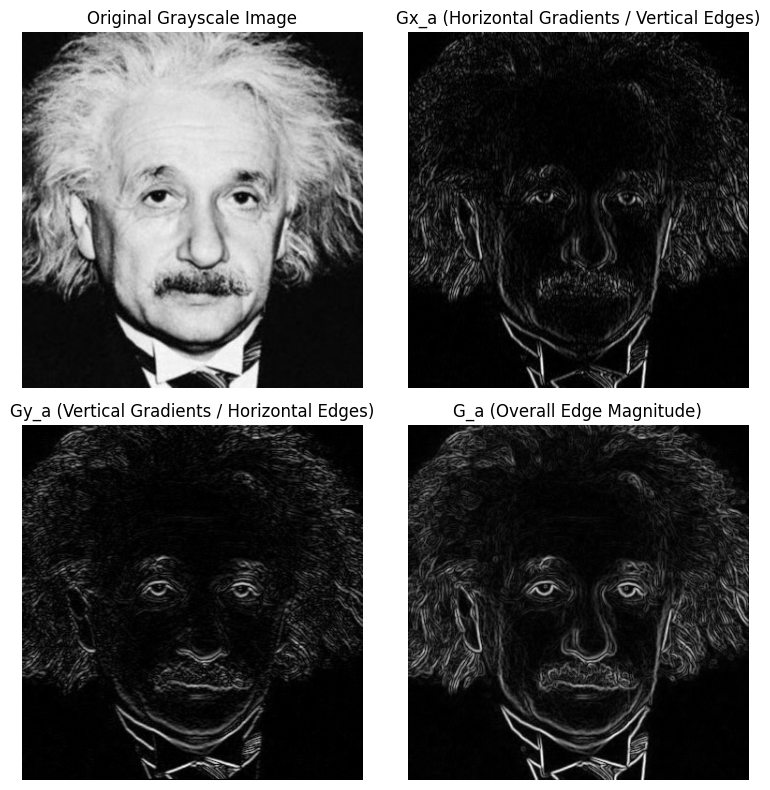

In [53]:
im_5 = cv2.imread("images/WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg", cv2.IMREAD_GRAYSCALE)

# Standard Sobel Kernels (3x3)
K_x = np.array([[-1, 0, 1], 
                [-2, 0, 2], 
                [-1, 0, 1]], dtype=np.float32)

K_y = np.array([[-1, -2, -1], 
                [ 0,  0,  0], 
                [ 1,  2,  1]], dtype=np.float32)

# OpenCV filter2D
Gx_a = cv2.filter2D(im_5, cv2.CV_64F, K_x)
Gy_a = cv2.filter2D(im_5, cv2.CV_64F, K_y)
G_a = np.hypot(Gx_a, Gy_a)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Original Grayscale Image
axes[0][0].imshow(im_5, cmap='gray')
axes[0][0].set_title('Original Grayscale Image')
axes[0][0].axis('off')

# Horizontal Gradient
axes[0][1].imshow(np.abs(Gx_a), cmap='gray')
axes[0][1].set_title('Gx_a (Horizontal Gradients / Vertical Edges)')
axes[0][1].axis('off')

# Vertical Gradient
axes[1][0].imshow(np.abs(Gy_a), cmap='gray')
axes[1][0].set_title('Gy_a (Vertical Gradients / Horizontal Edges)')
axes[1][0].axis('off')

# Total Gradient Magnitude
axes[1][1].imshow(G_a, cmap='gray')
axes[1][1].set_title('G_a (Overall Edge Magnitude)')
axes[1][1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def custom_conv2d(image, kernel):
    # 2D Convolution Function

    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    # Convert image to float64 for high-precision arithmetic
    padded = np.pad(image.astype(np.float64), ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    output = np.zeros_like(image, dtype=np.float64)

    # Correct loop bounds over image height and width
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i : i + kh, j : j + kw]
            output[i, j] = np.sum(region * np.flip(kernel))
    return output


Gx_b = custom_conv2d(im_5, K_x)
Gy_b = custom_conv2d(im_5, K_y)
G_b = np.hypot(Gx_b, Gy_b)

### (c) Separable 1D Filtering (Sobel Kernel Factorization)
### Sobel X = [1, 2, 1]^T * [-1, 0, 1]
### Sobel Y = [-1, 0, 1]^T * [1, 2, 1]

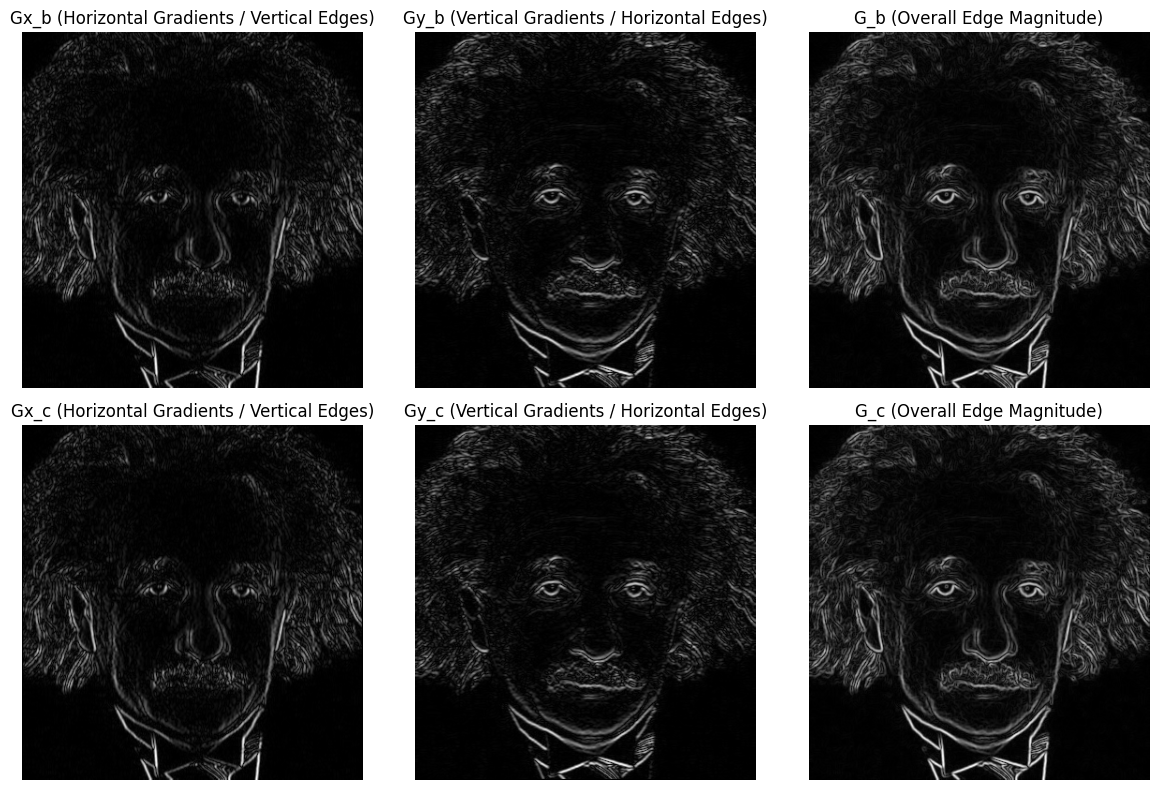

In [54]:
k_smoothing = np.array([[1], [2], [1]], dtype=np.float32) 
k_diff = np.array([[1, 0, -1]], dtype=np.float32)          

# Apply 1D horizontal pass followed by 1D vertical pass
Gx_c = cv2.sepFilter2D(im_5, cv2.CV_64F, k_diff, k_smoothing)
Gy_c = cv2.sepFilter2D(im_5, cv2.CV_64F, k_smoothing.T, k_diff.T)
G_c = np.hypot(Gx_c, Gy_c)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Horizontal Gradient
axes[0][0].imshow(np.abs(Gx_b), cmap='gray')
axes[0][0].set_title('Gx_b (Horizontal Gradients / Vertical Edges)')
axes[0][0].axis('off')

# Vertical Gradient
axes[0][1].imshow(np.abs(Gy_b), cmap='gray')
axes[0][1].set_title('Gy_b (Vertical Gradients / Horizontal Edges)')
axes[0][1].axis('off')

# Total Gradient Magnitude
axes[0][2].imshow(G_b, cmap='gray')
axes[0][2].set_title('G_b (Overall Edge Magnitude)')
axes[0][2].axis('off')

axes[1][0].imshow(np.abs(Gx_c), cmap='gray')
axes[1][0].set_title('Gx_c (Horizontal Gradients / Vertical Edges)')
axes[1][0].axis('off')

# Vertical Gradient
axes[1][1].imshow(np.abs(Gy_c), cmap='gray')
axes[1][1].set_title('Gy_c (Vertical Gradients / Horizontal Edges)')
axes[1][1].axis('off')

# Total Gradient Magnitude
axes[1][2].imshow(G_c, cmap='gray')
axes[1][2].set_title('G_c (Overall Edge Magnitude)')
axes[1][2].axis('off')

plt.tight_layout()
plt.show()


### Question 8